In [ ]:
import sys
from pathlib import Path

sys.path.append(
    str(
        Path(
            "/home/simoneponcioni/Documents/01_PHD/03_Methods/HR-pQCT_database/01_CODE/src"
        )
    )
)
import statistics_hrpqct as statistics_hrpqct
import dataclasses_hrpqct as dataclass_hrpqct
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Import raw datafile from csv raw filepath#
dir_path = Path("../../00_DB/")
df = "HR-pQCT_database_expanded_2025-06-16_16-18.csv"
dataset_path = dir_path / df

In [ ]:
# Instantiate class Statistics for the nodaratis database#
name_combined = "Combined"
name_originator = "POS"

common_df = pd.read_csv(dataset_path, sep=",")
dataset = dataclass_hrpqct.HRpQCT_Dataset(df=common_df, hfe_expansion=True)

# extract only dataclass for one patient, it will determine which sex is the patient for further analysis
patient_UID = 25
df_patient = common_df[common_df["UID"] == patient_UID]
dataset_patient = dataclass_hrpqct.HRpQCT_Dataset(df=df_patient, hfe_expansion=True)
print(dataset_patient.Gender)
db_stats = statistics_hrpqct.Statistics(
    df=dataset.df,
    df_patient=dataset_patient.df,
    name="HRpQCT_common_database",
    originator="POS",
    savefig=True,
    showfig=True,
)

24    Female
Name: Gender, dtype: object


In [ ]:
# radar plot for different age steps: important!: define a patient to investigate female or male first
list_age = [37, 50, 63, 76, 89]

# Dataset properties
dataset_properties_r = [
    dataset.Radius_total_volumetric_bone_mineral_density_mg_HA_ccm,
    dataset.Radius_cortical_vBMD_mg_HA_ccm,
    dataset.Radius_trabecular_bone_volume_fraction,
    dataset.Radius_rel_cortical_thickness,
    dataset.Radius_da,
    dataset.Radius_yield_stress,
]

dataset_properties_t = [
    dataset.Tibia_total_volumetric_bone_mineral_density_mg_HA_ccm,
    dataset.Tibia_cortical_vBMD_mg_HA_ccm,
    dataset.Tibia_trabecular_bone_volume_fraction,
    dataset.Tibia_rel_cortical_thickness,
    dataset.Tibia_da,
    dataset.Tibia_yield_stress,
]

combined_dataset_properties = [dataset_properties_r, dataset_properties_t]
sites = ["Radius", "Tibia"]
# sites = ['Tibia', 'Radius']

### Quadratic fit implementation

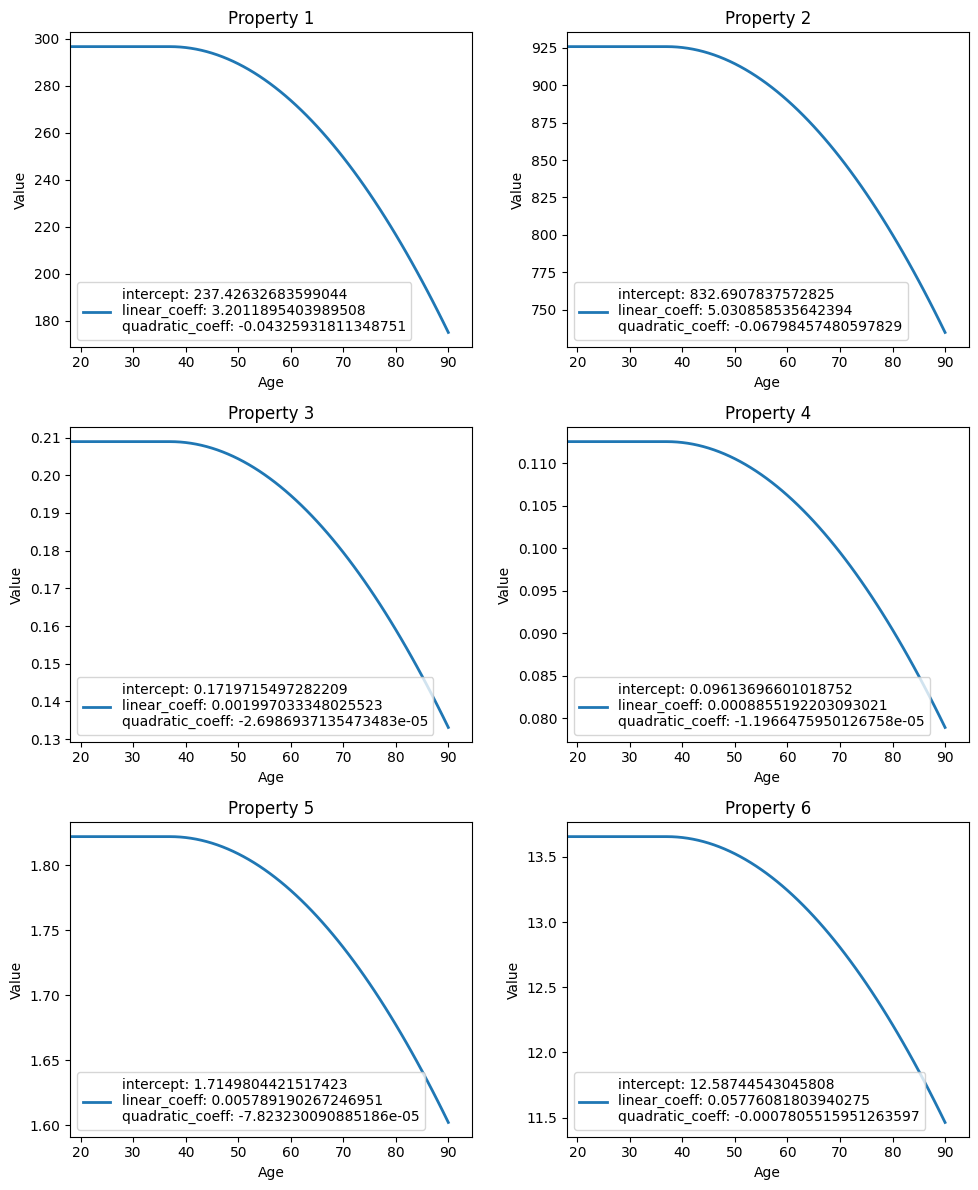

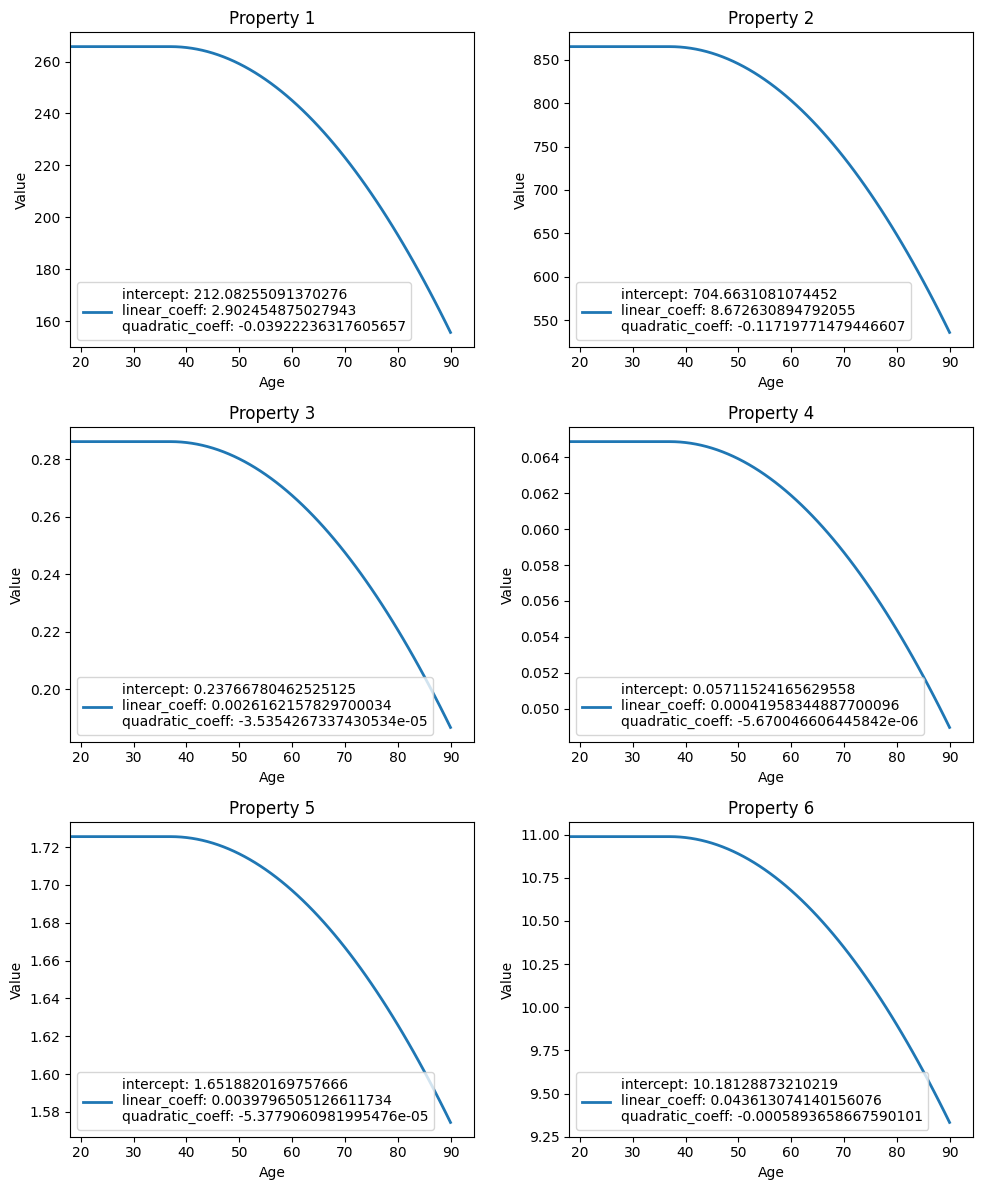

In [ ]:
for site, dataset_properties in zip(sites, combined_dataset_properties):
    # Calculate intercepts and slopes
    intercepts_slopes = [
        db_stats.quadratic_regression_constraint(
            dataset.Age[dataset_patient.Gender.values[0] == dataset.Gender],
            prop[dataset_patient.Gender.values[0] == dataset.Gender],
            37,
        )
        for prop in dataset_properties
    ]

    # Calculate parameter values at different ages
    list_params = [
        [intercept + linear_coeff * age + quadratic_coeff * age**2 for age in list_age]
        for intercept, linear_coeff, quadratic_coeff in intercepts_slopes
    ]

    # List of parameters at a specific age
    initial_values = [
        dataset.__avg_std__(prop, dataset_patient.df.Gender.values[0])[0]
        for prop in dataset_properties
    ]

    # Results for different ages
    results = [initial_values, *[list(param) for param in zip(*list_params)]]

    # Extract average values from __avg_std__
    avg_values = [
        dataset.__avg_std__(prop, dataset_patient.df.Gender.values[0])[0]
        for prop in dataset_properties
    ]

    ages = list(range(91))
    fig, axes = plt.subplots(3, 2, figsize=(10, 12))
    axes = axes.flatten()
    table_data = []
    # Dataset properties
    props_radius = [
        dataset.Radius_total_volumetric_bone_mineral_density_mg_HA_ccm,
        dataset.Radius_cortical_vBMD_mg_HA_ccm,
        dataset.Radius_trabecular_bone_volume_fraction,
        dataset.Radius_rel_cortical_thickness,
        dataset.Radius_da,
        dataset.Radius_ultimate_stress,
    ]

    props_tibia = [
        dataset.Tibia_total_volumetric_bone_mineral_density_mg_HA_ccm,
        dataset.Tibia_cortical_vBMD_mg_HA_ccm,
        dataset.Tibia_trabecular_bone_volume_fraction,
        dataset.Tibia_rel_cortical_thickness,
        dataset.Tibia_da,
        dataset.Tibia_ultimate_stress,
    ]

    for i, (avg, (intercept, linear_coeff, quadratic_coeff)) in enumerate(
        zip(avg_values, intercepts_slopes)
    ):
        y_values_0_37 = [avg] * 38
        y_values_37_90 = [
            intercept + linear_coeff * age + quadratic_coeff * age**2
            for age in range(37, 91)
        ]
        y_values = y_values_0_37 + y_values_37_90[1:]

        axes[i].plot(
            ages,
            y_values,
            label=f"intercept: {intercept}\nlinear_coeff: {linear_coeff}\nquadratic_coeff: {quadratic_coeff}",
            linewidth=2,
        )
        axes[i].set_xlabel("Age")
        axes[i].set_ylabel("Value")
        axes[i].set_xlim(18)
        axes[i].set_title(f"Property {i+1}")
        axes[i].legend()

        if "Radius" in site:
            table_data.append(
                [f"{props_radius[i]}", intercept, linear_coeff, quadratic_coeff]
            )
        elif "Tibia" in site:
            table_data.append(
                [f"{props_tibia[i]}", intercept, linear_coeff, quadratic_coeff]
            )
        else:
            table_data.append(
                [f"Property {i+1}", intercept, linear_coeff, quadratic_coeff]
            )

    plt.tight_layout()
    plt.show()

    # Custom formatting function
    def custom_format(x):
        if abs(x) > 1000 or (abs(x) < 0.001 and x != 0):
            return f"{x:.3e}"
        else:
            return f"{x:.3f}"

    df = pd.DataFrame(table_data, columns=["Property", "a", "b", "c"])
    styled_df = df.style.format(
        {
            "intercept": custom_format,
            "linear coefficient": custom_format,
            "quadratic coefficient": custom_format,
        }
    ).hide(axis=0)

    latex_table = styled_df.to_latex(
        column_format="lrrrr",
        position="h",
        position_float="centering",
        hrules=True,
        label="tab:linreg",
        caption="",
        multirow_align="t",
        multicol_align="r",
        clines=None,
    )
    # print(latex_table)
    # Calculate t-scores for all parameters
    t_scores = [[] for _ in range(len(list_age))]
    for i, prop in enumerate(dataset_properties):
        ref_avg, ref_std = dataset.__avg_std__(
            prop, dataset_patient.df.Gender.values[0]
        )
        for j in range(len(list_age)):
            t_score_value = db_stats.t_score(results[j][i], ref_avg, ref_std)
            t_scores[j].append(t_score_value)

    # Radar plot generation: saved as test_radar.png at the moment
    db_stats.savefig = True
    db_stats.get_radar_chart_paper(*t_scores, site)